In [1]:
%matplotlib inline

# This notebook was modified from https://github.com/JaysonAstro/prototype_HST_catalog_photometry/blob/main/HST_cats_with_IRAFStarFinder.ipynb
# which is based on https://qosmicqi.github.io/XRBID/chapters/photometry.html#sec-runphots
# and https://www.astropy.org/ccd-reduction-and-photometry-guide/v/pdev/notebooks/photometry/00.00-Preface.html


import glob 
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy import wcs
from astropy.wcs import WCS
from astropy.io import fits
from astropy.table import Table
from astropy.stats import SigmaClip
from astropy.stats import sigma_clipped_stats
from astropy.visualization import ZScaleInterval, ImageNormalize, LogStretch
from astropy.coordinates import SkyCoord, match_coordinates_sky

# Photutils imports
from photutils.background import Background2D, MedianBackground, SExtractorBackground
from photutils.detection import IRAFStarFinder, DAOStarFinder
from photutils.segmentation import SourceFinder, detect_sources
from photutils.segmentation import SegmentationImage
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats
from photutils.aperture import aperture_photometry
from photutils.profiles import CurveOfGrowth

/home/reho/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def convert_aperture_sum_Jy_per_sr_to_abmag(aperture_sum_jy_sr, header):
     '''Convert aperture sum in Jy/sr to AB magnitudes.
     Args:
          aperture_sum_jy_sr: aperture sum in Jy/sr or MJy/sr
          header: FITS header containing WCS information to get pixel area in steradians
                  and BUNIT for checking units of the input aperture sum.
     Returns:
          AB magnitudes'''
     
     # Check that the input is in Jy/sr
     if header.get('BUNIT', '').lower() in ['mjysr', 'mjy/sr', 'mj/steradian']:
          print(f"Warning: BUNIT in header is {header.get('BUNIT', 'unknown')}, but expected Jy/sr. Applying conversion to MJy/sr.")
          aperture_sum_jy_sr = np.array(aperture_sum_jy_sr) * 1e6
     elif not header.get('BUNIT', '').lower() in ['jy/sr', 'jy/steradian']:
          raise ValueError("Input aperture sum must be in Jy/sr for conversion to AB magnitudes.")
    
     # Get pixel area in steradians from header
     pix_area_sr = get_pixarea_in_sr(header)
     fnu_jy = np.array(aperture_sum_jy_sr) * pix_area_sr
     fnu_jy = np.where(fnu_jy > 0, fnu_jy, np.nan)
     # Converrt to magnitudes
     abmag = -2.5 * np.log10(fnu_jy / 3631.0)
     return abmag




def get_pixarea_in_sr(header):
    """Get pixel area in steradians from FITS header.
    Args:
        header: FITS header containing WCS information
    Returns:
        pixel area in steradians (float)"""
    
    # JWST data should have a PIXAR_SR keyword
    if 'PIXAR_SR' in header:
        return float(header['PIXAR_SR'])
    
    # If keyword is not found, then we can try to compute it from CDELT or CD matrix
    elif ('CDELT1' in header) and ('CDELT2' in header):
        print("Warning: PIXAR_SR keyword not found in header. Attempting to compute pixel area from WCS information.")
        area_deg2 = np.abs(float(header['CDELT1']) * float(header['CDELT2']))
        if np.isfinite(area_deg2) and (area_deg2 > 0):
            return float((area_deg2 * u.deg**2).to(u.sr).value)
    elif 'CD1_1' in header:
        print("Warning: PIXAR_SR keyword not found in header. Attempting to compute pixel area from WCS information.")
        cd = np.array([[float(header['CD1_1']), float(header['CD1_2'])],
                        [float(header['CD2_1']), float(header['CD2_2'])]])
        area_deg2 = np.abs(np.linalg.det(cd))
        return float((area_deg2 * u.deg**2).to(u.sr).value)
    # And if we can't do either of those...
    else:
        raise ValueError("could not get pixel area in steradians from header/WCS")
     


def open_jwst(path, gal, dir, band, level, mosaic_ext="*i2d_anchor.fits", get_coverage=True):
    """
    Open JWST data (from either MIRI/NIRCam) and return image, error, header.
    Using the stage 3 aligned data products, and it defaults to the anchored mosaic (which is the most aligned product).

    Args:
        path: path to the data directory
        gal: galaxy name
        dir: directory name
        band: filter name (e.g., F770W, F1000W, etc.)
        level: useful if data is hidden in a subdirectory (typical for pjpipe outputs)
        mosaic_ext: extension to search for (default is the anchored mosaic)
        get_coverage: whether to return a coverage mask (default True)
    Returns:
        img: 2D array of the image data
        err: 2D array of the error data
        snr_map: 2D array of the signal-to-noise ratio (img/err)
        coverage_mask: 2D boolean array where True indicates no coverage (NaN or zero in img or err)
        header: FITS header of the image data
    """
    # Load the files
    print(f"Searching in {path} for {band} data, with extension: {mosaic_ext}")
    files = glob.glob(f"{path}/{gal.lower()}*{band.lower()}*{mosaic_ext}")
    print(f"Files found: {files}")
    
    # Sanity check that we are getting only one aligned mosaic
    if len(files) == 0:
        raise FileNotFoundError(f"No files found for {band} in {dir}{gal}")
    elif len(files) > 1:
        print(f"Warning: Multiple files found for {band} in {dir}{gal}. Using the first one: {files[0]}")

    # Initialize variables
    img_file = None
    err_file = None

    # Open the file and use extensions to assign data and header
    with fits.open(files[0]) as hdul:
        img_file = hdul['SCI']
        img = img_file.data
        header = img_file.header
        # Error
        err_file = hdul['ERR']
        err = err_file.data
        err_header = err_file.header
    # Check the names of the image and error extensions 
    print(f"Image file: {img_file}")
    print(f"Error file: {err_file}")

    # Handle NaNs and zeros
    snr_map = np.full_like(img, np.nan)
    valid = (np.isfinite(img)) & (np.isfinite(err)) & (err > 0)
    snr_map[valid] = img[valid] / err[valid]

    # Coverage mask
    if get_coverage:
        coverage_mask = (~np.isfinite(img)) | (img == 0) | (err == 0)
    else:
        coverage_mask = None

    return img, err, snr_map, coverage_mask, header

In [ ]:
def subtract_bkg(img, box_size=(50,50), filter_size=(3, 3), bkg_estimator=MedianBackground(), coverage_mask=None):
     """Estimate and subtract background from image using Background2D.
     Args:
          img: 2D array of image data
          box_size: size of boxes for background estimation (in pixels)
          filter_size: size of median filter to apply to background (in pixels)
          bkg_estimator: background estimator to use (default is MedianBackground())
          coverage_mask: boolean array where True indicates pixels to exclude from background estimation 
                         (e.g., due to low coverage or bad data). If None, no mask is applied.
     Returns:
          img_sub: background-subtracted image
          bkg_mean: mean background level (in same units as img)
          bkg_rms: background RMS (in same units as img)"""
     
     # estimate background
     # TODO: need to include valid mask based on weight image or other metric
     sigma_clip = SigmaClip(sigma=3.0)

     if coverage_mask is None:
          print(f"creating coverage mask")
          coverage_mask = (~np.isfinite(img)) | (img == 0)

     bkg = Background2D(
          img,
          box_size=box_size,
          filter_size=filter_size,
          sigma_clip=sigma_clip,
          bkg_estimator=bkg_estimator,
          coverage_mask=coverage_mask,
          )

     rms_map = np.array(bkg.background_rms, dtype=float)
     valid_rms = (~coverage_mask) & np.isfinite(rms_map) & (rms_map > 0)

     #print(f"bkg array {bkg.background}")
     bkg_rms = np.nanmedian(rms_map[valid_rms]) if np.any(valid_rms) else np.nan
     bkg_mean = np.nanmean(np.asarray(bkg.background, dtype=float)[~coverage_mask])
     print(f"Mean background: {bkg_mean}")
     print(f"Background rms: {bkg_rms}")
     print(f"Subtracting background...")
     img_sub = img - bkg.background
     print(f"Background subtraction complete.")

     return img_sub, bkg_mean, bkg_rms, bkg.background



def run_source_finder(img, header, rms, finder='iraf', snr_threshold=3.0, fwhm=2.0,
     roundlo=-0.5, roundhi=0.5, sharplo=0.2, sharphi=1.0, brightest=50000):
     """Find sources in the image using IRAFStarFinder.
     Args:
          img: 2D array of background-subtracted image data
          header: FITS header of the image (used for WCS and pixel scale)
          rms: background RMS (in same units as img)
          finder: source finder to use (currently only 'iraf' supported)
          snr_threshold: signal-to-noise ratio threshold for source detection
          fwhm: FWHM of the PSF in pixels (used for source detection)
          roundlo, roundhi: roundness limits for source selection
          sharplo, sharphi: sharpness limits for source selection
          brightest: if not None, only return this many brightest sources in the catalog
     Returns:
          sources: Table of detected sources with columns xcentroid, ycentroid, flux, sharpness, roundness, mag, peak, etc."""
     # Run the source finder
     print(f"Running source finder: {finder}")
     ths = snr_threshold * rms
     if finder == 'iraf':
          # IRAF always uses circular Gaussian kernels and calculates object's centroid, roundness,
          # and sharpness using imagemoments. 
          source_finder = IRAFStarFinder(threshold=ths,
               fwhm=fwhm,
               roundlo=roundlo,
               roundhi=roundhi,
               sharplo=sharplo,
               sharphi=sharphi,
               brightest=brightest,
          )
     elif finder == 'dao':
          # DAO can also use elliptical apertures.
          source_finder = DAOStarFinder(threshold=ths,
               fwhm=fwhm,
               roundlo=roundlo,
               roundhi=roundhi,
               sharplo=sharplo,
               sharphi=sharphi,
               brightest=brightest,
          )
     # elif finder == 'peaks':
     #      # find_peaks looks for local maxima above a specified threshold, 
     #      # and can use a box size to define the neighborhood for peak detection.
     #      # Requires a bit of extra work to get results in the same format as IRAFStarFinder/DAOStarFinder, 
     #      # and it doesn't calculate sharpness or roundness.
     #      # TODO: Add function converting find_peaks output to a table with xcentroid, ycentroid, flux, etc.
     #      source_finder = find_peaks(img, 
     #           threshold=ths, 
     #           box_size=fwhm*2,
     #           centroid_func=centroid_quadratic,
     #      )
     else:
          raise ValueError(f"Starfinder {finder} not recognized. Currently only 'iraf' supported.")
     #
     # TODO: Add functionality for source finding using a segmentation map (e.g., using 
     # detect_sources/SourceFinder) instead of IRAFStarFinder or DAOStarFinder.
     # Segmentation gets more information about the source shape rather than assuning it's point-like, 
     # giving a precise isophotal boundary. Useful for extended sources and crowded fields, 
     # but more computationally expensive and may require more tuning of parameters.
     # It is also better for source deblending.

     # Run the source finder
     sources = source_finder(img)
     print(f"Found {len(sources)} sources")
     print(sources.colnames)
     return sources


In [37]:
def get_optimal_aperture(data, sources, max_r=32, brightest=50, frac=0.95, plot=True):
     """Find the optimal aperture radius to use for the photometry. 
     Args:
          data: 2D array of image data (background-subtracted)
          sources: Table of sources from source finder 
                   (must contain xcentroid, ycentroid, flux)
          max_r: maximum aperture radius to test (in pixels)
          brightest: if not None, only use this many brightest sources to compute curve of growth
          frac: fraction of total flux to use as criterion for optimal radius 
          (e.g., 0.95 means radius where median curve of growth reaches 95% of total flux)
          plot: if True, plot the curve of growth and optimal radius
          
     Returns:
          r_opt: optimal aperture radius in pixels (to use with compute_photometry)"""
     
     # Select only the brightest sources to compute the curve of growth
     if brightest is not None:
          sources = sources[np.argsort(sources['flux'])[-brightest:]]
          print(f"Using only {len(sources)} sources.")

     print("Doing aperture photometry...")
     positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
     radii = np.arange(1, max_r)

     # Define in and outer annuli for local background estimation
     # TODO: optimize values for the sky annulus 
     ann_in, ann_out = max_r + 2, max_r + 8
     ann = CircularAnnulus(positions, r_in=ann_in, r_out=ann_out)

     # Get local backgrounds
     # TODO: consider impact of extended emission on local background. 
     ann_phot = aperture_photometry(data, ann)
     bkg_mean = np.asarray(ann_phot["aperture_sum"]) / ann.area

     # At each radius, compute photometry
     fluxes = []
     for r in radii:
          ap = CircularAperture(positions, r=r)
          phot = aperture_photometry(data, ap)

          # Subtract local background
          src = np.asarray(phot["aperture_sum"]) - bkg_mean * ap.area
          fluxes.append(src)

     # Normalize fluxes for computing the curve of growth
     fluxes = np.asarray(fluxes).T

     norm = fluxes / fluxes[:, [-1]]
     norm[~np.isfinite(norm)] = np.nan

     # comptue median normalized flux
     median_curve = np.nanmedian(norm, axis=0)  
     # Get the index of the radius where the curve of growth reaches the specified fraction of total flux
     idx = np.where(median_curve >= frac)[0]
     r_opt = radii[idx[0]] if len(idx) else radii[np.nanargmax(median_curve)]
     print(f"Optimal aperture radius: {r_opt}")

     if plot:
          plt.figure()
          plt.plot(radii, median_curve, marker='o')
          plt.axvline(r_opt, color='red')
          plt.xlabel("Aperture radius (pixels)")
          plt.ylabel("Normalized flux")
          plt.title("Curve of growth")
          plt.grid(True)

     return r_opt



def compute_photometry(data, header, sources, r_opt=10, sky_in=12, sky_out=18, brightest=None, write=False, outdir='./'):
     """Compute aperture photometry for sources and return catalog with RA, Dec, magnitudes, etc.
     
     Args:
          data: 2D array of image data (background-subtracted)
          header: FITS header of the image
          sources: Table of sources from source finder 
                   (must contain xcentroid, ycentroid, flux, sharpness, roundness, mag, peak)
          r_opt: optimal aperture radius
          brightest: if not None, only use this many brightest sources for photometry
          write: if True, write catalog to outdir with name {gal}_jwst_{band}_cat.fits
          outdir: directory to write catalog if write=True

     Returns:
          phot_full: Table with photometry results, including RA, Dec, aperture sum, magnitudes, etc.
     """

     if brightest is not None:
          # Aperture photometry of only brightest sources
          sources = sources[np.argsort(sources['flux'])[-brightest:]]
          print(f"using only {len(sources)} sources")

     # Do aperture photometry
     print(f"Doing aperture photometry...")
     positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
     apertures = CircularAperture(positions, r=r_opt)
     aper_stats = ApertureStats(data, apertures)
     phot_full = aperture_photometry(data, apertures, method='exact')

     # Annulus
     annuli = CircularAnnulus(positions, r_in=sky_in, r_out=sky_out)
     annuli_stats = ApertureStats(data, annuli)
     sigma_clip_bkg = SigmaClip(sigma=3.0, maxiters=5)
     # mask = annuli.to_mask(method='exact')
     # Mask the data to exclude NaNs and infs from the background estimation
     mask = ((np.isinf(data)) | (np.isnan(data)))

     # Background annulus stats
     bkg_stats = ApertureStats(data, annuli, sigma_clip=sigma_clip_bkg, mask=mask, sum_method='exact')
     bkg_median = bkg_stats.median
     bkg_median[np.isnan(bkg_median)]=0
     area_aper = aper_stats.sum_aper_area.value
     area_annulus = bkg_stats.sum_aper_area.value
     total_bkg = bkg_median * area_aper

     # Subtract background from aperture sum
     phot_full['aperture_sum'] = phot_full['aperture_sum'] - total_bkg

     # Copy source-finder morphology columns
     phot_full['flux'] = np.asarray(sources['flux'])
     phot_full['sharpness'] = np.asarray(sources['sharpness'])
     if 'roundness' in sources.colnames:
          phot_full['roundness'] = np.asarray(sources['roundness'])          
     phot_full['finder_mag'] = np.asarray(sources['mag'])
     phot_full['peak'] = np.asarray(sources['peak'])

     # Include ra, dec
     wcs = WCS(header)
     ra, dec = wcs.all_pix2world(phot_full["xcenter"], phot_full["ycenter"], 0)
     phot_full["ra"] = ra
     phot_full["dec"] = dec

     # Convert flux from the source finder in table (converted to AB magnitudes)
     phot_full['finder_flux_abmag'] = convert_aperture_sum_Jy_per_sr_to_abmag(sources['flux'], header=header)
     # Aperture sum from circular aperture photometry (converted to AB magnitudes)
     phot_full['aperture_sum_abmag'] = convert_aperture_sum_Jy_per_sr_to_abmag(phot_full['aperture_sum'], header=header)

     # Sort by aperture flux
     phot_full.sort("aperture_sum")
     phot_full.reverse()

     # Print the column names of the photometry table
     print(phot_full.colnames)

     # Write the catalog if requested
     if write:
          cat_name = f"{gal}_jwst_{band}_cat.fits"
          print(f"Writing catalog to {outdir + cat_name}")
          phot_full.write(outdir + cat_name, overwrite=True)

     return apertures, phot_full

In [5]:
# Photometric calibration
def eq_coords(phot, img):
    """Get the RA and Dec information from the WCS and pixel coordinates."""
    phot['ra'] = phot['x']
    phot['dec'] = phot['y']
    for a in phot:
        rd = img.meta.wcs.transform('detector', 'world', a['x'], a['y'])
        a['ra'] = rd[0]
        if (a['ra'] > 180):
            a['ra'] -= 360
        a['dec'] = rd[1]

# Load in the catalogs that are produced by the image3pipeline
def get_image3_catalog(filedir, filter, galaxy, level='lv3'):
    cat_dir = filedir
    # cat_dir = dir + f"{galaxy}/{filter.upper()}/{level}"
    cat_filename = f"{galaxy}_nircam_{level}_{filter.lower()}_cat_align.ecsv"
    cat_name = cat_dir + "/" + cat_filename
    return cat_name


# Cross match the catalog that we have made with the outputs of the image3pipeline
def cross_match_catalogs(dir, filter, galaxy, phot_full, cat_image3):
    cat_name = get_image3_catalog(dir, filter, galaxy=galaxy)
    calib_cat = Table.read(cat_name, format='ascii.ecsv')
    # phot_full['ra'] = phot_full['ra'] - delta_ra
    # phot_full['dec'] = phot_full['dec'] - delta_dec

    # Use proximity based approach to cross match the catalogs
    calib_coords = SkyCoord(ra=calib_cat['ra'] * u.deg, dec=calib_cat['dec'] * u.deg)
    # My photometry into Sky Coords
    phot_coords = SkyCoord(ra=phot_full['ra'] * u.deg, dec=phot_full['dec'] * u.deg)
    # Match coordinates
    ind_2d_cat, dist_2d, _ = match_coordinates_sky(phot_coords, calib_coords)
    return ind_2d_cat, dist_2d, phot_full

In [6]:
# Empirical filter FWHM
# NIRCAM from https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-performance/nircam-point-spread-functions#gsc.tab=0
# MIRI from https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-performance/miri-point-spread-functions#gsc.tab=0
filter_fwhm = {
    'F150W': 1.613,
    'F164N': 1.806,
    'F187N': 2.065,
    'F200W': 2.129,
    'F212N': 2.323,
    'F277W': 1.460,
    'F300M': 1.587,
    'F335M': 1.762,
    'F360M': 1.905,
    'F405N': 2.159,
    'F444W': 2.302,
    'F770W': 2.445,
    'F1000W': 2.982,
    'F1130W': 3.409,
    'F2100W': 6.127,
}

### Aperture photometry on JWST data

This notebook performs basic aperture photometry on JWST data. It is set up to work with the outputs of pjpipe and was tested on files in the MPCDF directory structure. So far, the tests have only used NIRCam data, but MIRI should behave the same and will be tested soon. 

To start, we need to define some paths to our data. The cell below is also where we will chose the galaxy and filter that we want to run our photometry on. 

In [7]:
# Path to my directory and the folder that I want outputs to be saved to
root_dir = "/nexus/posix0/MIA-astro-env/eschinner/reho/"
outdir = root_dir + "centres/catalogs_using_v2p0"

# Path to the shared directory with all of the JWST data
# jwst_dir = "/nexus/posix0/MIA-astro-env/eschinner/shared/PHANGS/JWST/v4p1/4793/nircam/reprocess/v4p1/"
# Currently running locally while the new reduction is happening
jwst_dir = root_dir + "centres/data/v4p1_temp/"

# ------------------------------------
# This is where we set our parameters!
gal = 'ngc2997'
inst = 'nircam'
level = 'anchoring'
mosaic_ext = 'i2d_anchor.fits'
band = 'f150w'
sci_ext = 0 # Which header extension we want the data from
# ------------------------------------

# Turn this into a filename and a path
filename = gal + "_" + inst + "_lv3_" + band + "_" + mosaic_ext
# path = jwst_dir + gal + "/" + band.upper() + "/" + level + "/"
path = jwst_dir# + filename

Set all of the photomertry parameters here, to avoid hard coding:

In [41]:
# Source detection parameters

# TODO: DAO compatibility
finder = 'iraf' # Make sure this is 'iraf' for now

# TODO: set up config file
snr_threshold = 3.0         # Signal-to-noise ratio threshold for source detection
fwhm = 2.0                  # Will be overwritten by filter FWHM later
use_filter_fwhm = False     # If True, this overwrites the default FWHM with the empirical value for appropriate filter.
box_size = (50,50)
filter_size = (3,3)
roundlo = -0.5
roundhi = 0.5
sharplo = 0.2
sharphi = 1.0
nsources = 10000 # if not None, only return this many brightest sources from the source finder

# Finding optimal aperture parameters
max_r = 20
brightest_ropt = 50
frac = 0.95
plot_ropt = True
# Photometry parameters
brightest_phot = None # if not None, only do photometry on this many brightest sources in the catalog

bkg_estimator = SExtractorBackground() # Could also be set to e.g. MedianBackground().

Update the FWHM according to the filter PSF.

In [9]:
if use_filter_fwhm:
     try:
          fwhm = filter_fwhm[band.upper()]
          print(f"Using FWHM of {fwhm} pixels for source detection based on JWST PSF for {band.upper()}.")
     except KeyError:
          print(f"Warning: FWHM for {band.upper()} not found in filter_fwhm dictionary. Using default FWHM of {fwhm} pixels for source detection.")


Now we can start running the photometry. 



Searching in /nexus/posix0/MIA-astro-env/eschinner/reho/centres/data/v4p1_temp/ for f150w data, with extension: i2d_anchor.fits
Files found: ['/nexus/posix0/MIA-astro-env/eschinner/reho/centres/data/v4p1_temp/ngc2997_nircam_lv3_f150w_i2d_anchor.fits']
Image file: <astropy.io.fits.hdu.image.ImageHDU object at 0x7f96c6c684a0>
Error file: <astropy.io.fits.hdu.image.ImageHDU object at 0x7f96c6c6a150>
Mean background: 1.3289097080152799
Background rms: 0.3083134937739853
Subtracting background...
Background subtraction complete.


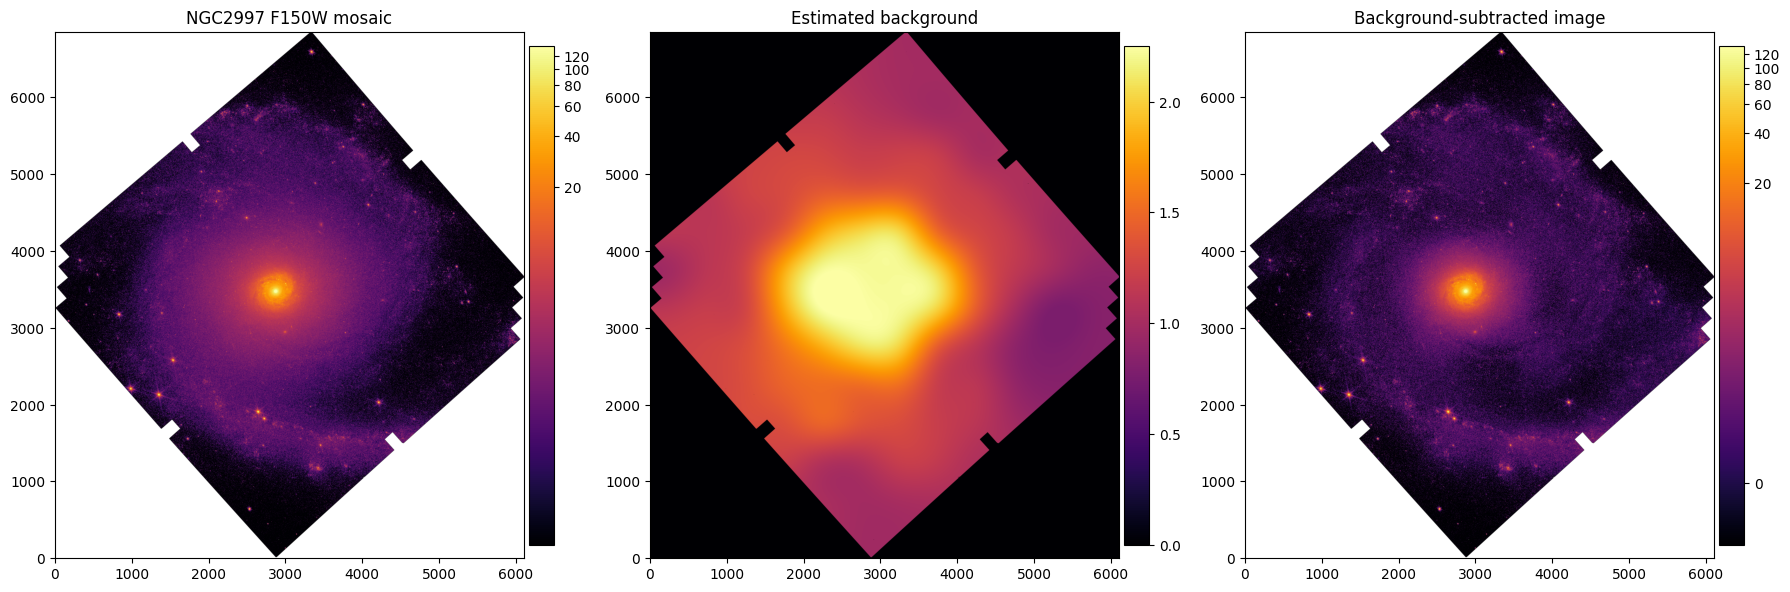

In [42]:
# Open the JWST data file abd get the image, error, SNR map, coverage mask, and header
img, err, snr_map, coverage_mask, header = open_jwst(
     path=path, 
     gal=gal, 
     dir=jwst_dir, 
     band=band, 
     level=level, 
     mosaic_ext=mosaic_ext
)

# Subtract background and return the background subtracted image, mean background level, 
# background RMS, and the overall background map (for plotting)
img_sub, bkg_mean, bkg_rms, bkg_background = subtract_bkg(
     img=img, 
     bkg_estimator=bkg_estimator, 
     coverage_mask=coverage_mask
)
# TODO: background subtracted data from PJPipe?


# Plot the image, background, and background-subtracted image
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
norm = ImageNormalize(vmin=np.nanpercentile(img, 25.00), 
                      vmax=np.nanpercentile(img, 99.99), 
                      stretch=LogStretch())
ax[0].imshow(img, origin='lower', cmap='inferno', norm=norm)
ax[0].set_title(f"{gal.upper()} {band.upper()} mosaic")
ax[1].imshow(bkg_background, origin='lower', cmap='inferno')
ax[1].set_title(f"Estimated background")
norm_sub = ImageNormalize(vmin=np.nanpercentile(img_sub, 25.00), 
                          vmax=np.nanpercentile(img_sub, 99.99), 
                          stretch=LogStretch())
ax[2].imshow(img_sub, origin='lower', cmap='inferno', norm=norm_sub)
ax[2].set_title(f"Background-subtracted image")
# Add colourbars
for a in ax:
     im = a.images[0]
     plt.colorbar(im, ax=a, pad=0.01, fraction=0.05)
plt.tight_layout()
plt.show()

In [23]:
# Get the unit from the header
print(f"Image units from header: {header.get('BUNIT', 'unknown')}")

Image units from header: MJy/sr


Now that we have a background subtracted image, we can start detecting sources. There are two options to use here, (1) is the IRAFStarFinder and the other is (2) DAOStarFinder. The main difference is that IRAF always uses circular Gaussian kernels and calculates object's centroid, roundness, and sharpness using image moments. DAO can use elliptical apertures and may be more useful for source finding in regions with a lot of extended emission. 

In [11]:
# Get sources using the source finder
sources = run_source_finder(
    img=img_sub, 
    header=header, 
    rms=bkg_rms, 
    finder=finder, 
    snr_threshold=snr_threshold, 
    fwhm=fwhm,
    brightest=nsources
)

# Alternatively, load in a catalog computed by another method here.

print(sources)

Running source finder: iraf
Found 10000 sources
['id', 'xcentroid', 'ycentroid', 'fwhm', 'sharpness', 'roundness', 'pa', 'npix', 'peak', 'flux', 'mag']
  id      xcentroid      ...        flux                mag        
----- ------------------ ... ------------------ -------------------
    1 2527.7533881453296 ...  23872.29840725762 -10.944735586429257
    2 2489.8954093278517 ... 22015.520505091954 -10.856822394465805
    3 3450.2194632775963 ...  16205.53476112978  -10.52415841686486
    4 4070.2521992179472 ... 15539.889492607703   -10.4786198152933
    5   4003.39666488814 ... 12552.001425382216 -10.246782449741417
    6   5372.00086775524 ... 11065.591139175584 -10.109936548736474
    7  323.7166306577174 ... 10409.511070077795  -10.04357582844639
    8  5218.739621316173 ...  9531.920438225521  -9.947951021716515
    9 1725.6661540109087 ...  8673.991908073149  -9.845547531654056
   10 2496.3991345045033 ...  8359.263595760978  -9.805420050540107
  ...                ... ...    

Get/set the aperture radius before doing the photometry.

Computing optimal aperture for photometry...
Using only 50 sources.
Doing aperture photometry...
Optimal aperture radius: 11
Setting aperture radius to 11 pixels for photometry.
Large r_opt. Using PSF FWHM rather than curve of growth for photometry.


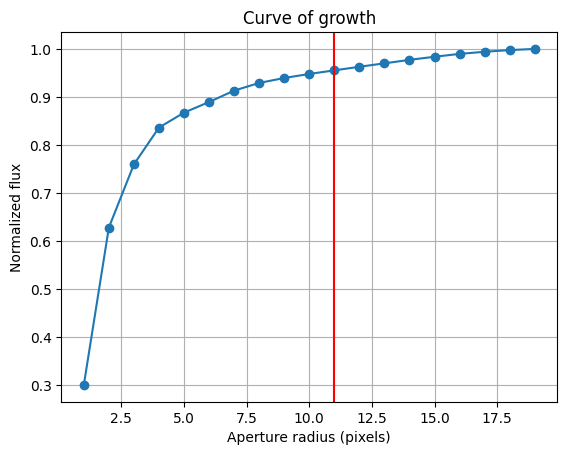

In [12]:
print(f"Computing optimal aperture for photometry...")

# Either get the optimum radius based on curve of growth...
r_opt = get_optimal_aperture(
    data=img_sub, 
    sources=sources,
    max_r=max_r, 
    brightest=brightest_ropt, 
    frac=frac, 
    plot=plot_ropt
)

# ...or just set it to a fixed value (e.g., based on the PSF FWHM)
print(f"Setting aperture radius to {r_opt} pixels for photometry.")
# Check r_opt relative to the FWHM of the filter:
if r_opt > 3 * fwhm:
    print("Large r_opt. Using PSF FWHM rather than curve of growth for photometry.")
    r_opt = 2.5 * fwhm

Photometry time!

In [39]:
# Perform photometry with circular apertures
print(f"Performing photometry on {len(sources)} sources with aperture radius of {r_opt} pixels.")
apertures, catalog = compute_photometry(
    data=img_sub, 
    header=header, 
    sources=sources, 
    r_opt=r_opt, 
    brightest=brightest_phot, 
    write=False, 
    outdir=outdir
)

Performing photometry on 10000 sources with aperture radius of 5.0 pixels.
Doing aperture photometry...
['id', 'xcenter', 'ycenter', 'aperture_sum', 'flux', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']


Set OBSGEO-B to    10.072071 from OBSGEO-[XYZ].
Set OBSGEO-H to 1690612669.233 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Congrats, you've done aperture photometry. 

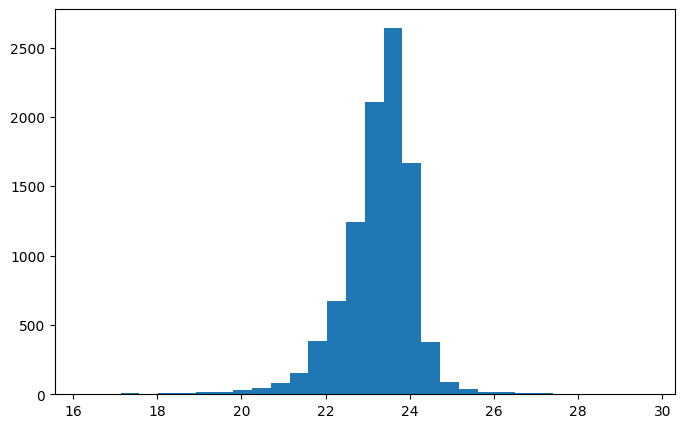

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(catalog['aperture_sum_abmag'], bins=30)
plt.show()

## Applying corrections

The catalogs that we get out of this process aren't going to be calibrated to JWST data specifically. We've already converted our fluxes to AB magnitudes as part of the aperture photometry step, but to truly get our data into AB mags, that can be used for comparison to other catalogs, we also need to apply a zero point correction. The set of zero points for each NIRCam detector that were delivered back in cycle 1 are available here: https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-performance/nircam-absolute-flux-calibration-and-zeropoints#NIRCamAbsoluteFluxCalibrationandZeropoints-NRC_zeropoints&gsc.tab=0 . However, these are updated with every CRDS release.

To calculate the zero point that we need to apply, we can compare our AB magnitudes to a catalog produced by PJPipe. Note that *this catalog is unoptimized and not science ready*. I am working on a method of calculating the zero points in a more robust way that does not rely on the default pjpipe catalogs. However, for now, this is what we've got.


In [14]:
# Get the associated catalog from the image3pipeline
cat_name = get_image3_catalog(jwst_dir, band, galaxy=gal)
calib_cat = Table.read(cat_name, format='ascii.ecsv')
print(f"Catalog from image3pipeline: {cat_name}")
print(f"Catalog columns: {calib_cat.colnames}")
# Check that this is a real file and not a pattern that doesn't match anything
if not glob.glob(cat_name):
    print(f"Warning: No catalog found for {band} in {gal} at {cat_name}")

Catalog from image3pipeline: /nexus/posix0/MIA-astro-env/eschinner/reho/centres/data/v4p1_temp//ngc2997_nircam_lv3_f150w_cat_align.ecsv
Catalog columns: ['label', 'xcentroid', 'ycentroid', 'sky_centroid', 'aper_bkg_flux', 'aper_bkg_flux_err', 'aper30_flux', 'aper30_flux_err', 'aper50_flux', 'aper50_flux_err', 'aper70_flux', 'aper70_flux_err', 'aper_total_flux', 'aper_total_flux_err', 'aper30_abmag', 'aper30_abmag_err', 'aper50_abmag', 'aper50_abmag_err', 'aper70_abmag', 'aper70_abmag_err', 'aper_total_abmag', 'aper_total_abmag_err', 'aper30_vegamag', 'aper30_vegamag_err', 'aper50_vegamag', 'aper50_vegamag_err', 'aper70_vegamag', 'aper70_vegamag_err', 'aper_total_vegamag', 'aper_total_vegamag_err', 'CI_50_30', 'CI_70_50', 'CI_70_30', 'is_extended', 'sharpness', 'roundness', 'nn_label', 'nn_dist', 'isophotal_flux', 'isophotal_flux_err', 'isophotal_abmag', 'isophotal_abmag_err', 'isophotal_vegamag', 'isophotal_vegamag_err', 'isophotal_area', 'semimajor_sigma', 'semiminor_sigma', 'elliptic

In [15]:
# Get the pixel scale by instrument and filter
# with fits.open(jwst_dir + gal + "/" + band.upper() + "/" + level + "/" + filename) as hdul:
with fits.open(jwst_dir + filename) as hdul:
    head_for_pixel_scale = hdul[sci_ext].header
if head_for_pixel_scale['INSTRUME'] == 'NIRCAM':
    if head_for_pixel_scale['CHANNEL'] == 'SHORT':
        pixel_scale = 0.031
    else:
        pixel_scale = 0.063
elif head_for_pixel_scale['INSTRUME'] == 'MIRI':
    pixel_scale = 0.11
print(f"Pixel scale for {band.upper()} is {pixel_scale} arcsec/pixel.")

Pixel scale for F150W is 0.031 arcsec/pixel.


We want to make sure we're comparing catalogs with the same flux enclosed in the apertures to get the zero point. We therefore create a new catalog here with r_opt=0.7, and ocmpare this to the aper70_mag column of the calib catalog. Note: with source crowding and poor background subtraction, r_opt70 likely isn't accurate here. Improvements in progress. 

Using only 50 sources.
Doing aperture photometry...
Optimal aperture radius: 3
using only 1000 sources
Doing aperture photometry...
['id', 'xcenter', 'ycenter', 'aperture_sum', 'flux', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']


Set OBSGEO-B to    10.072071 from OBSGEO-[XYZ].
Set OBSGEO-H to 1690612669.233 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


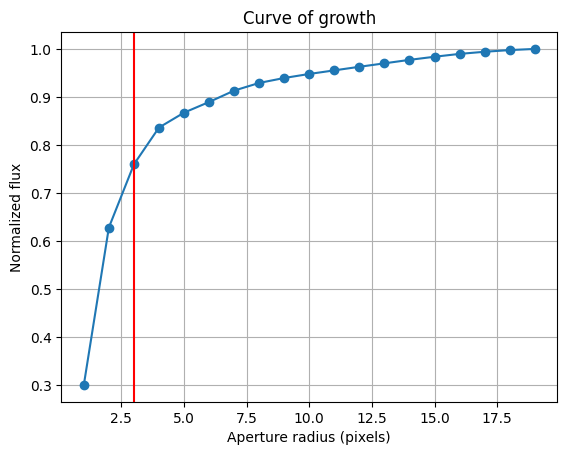

In [16]:
r_opt70 = get_optimal_aperture(img_sub, sources, max_r=20, brightest=50, frac=0.7, plot=True)
aper70, cat70 = compute_photometry(img_sub, header, sources, r_opt=r_opt70, brightest=1000, write=False, outdir=outdir)

Median absolute offset in RA: -0.010 arcsec
Median absolute offset in Dec: -0.005 arcsec


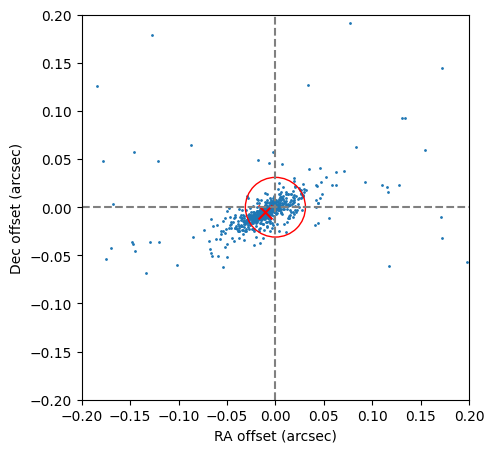

Number of matched sources: 490
['id', 'xcenter', 'ycenter', 'aperture_sum', 'flux', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag']
Magnitude zero point offset (median): -27.591


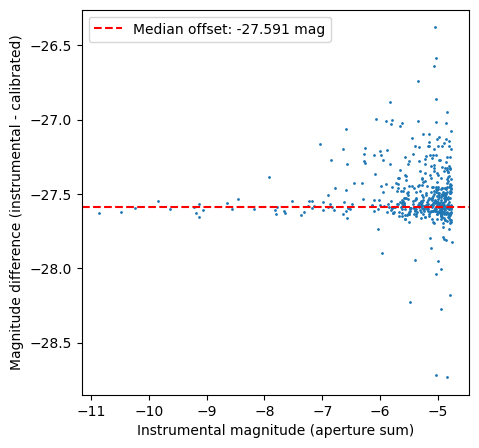

In [17]:
def plot_catalog_comparison(phot, calib_cat, ind_2d_cat, pixel_scale=0.031):
    """Plot the RA and Dec offsets between the photometry catalog and the calibration catalog.
    Args: 
        phot: Table of photometry results from compute_photometry (must contain 'ra' and 'dec' columns)
        calib_cat: Table of calibration catalog from image3pipeline (must contain 'ra' and 'dec' columns)
        ind_2d_cat: indices of the matched sources in the calibration catalog (from cross_match_catalogs)
        pixel_scale: pixel scale of the image in arcseconds/pixel (used to plot a circle representing the pixel scale)
     Returns:
        delta_ra: array of RA offsets in arcseconds between phot and calib_cat for the matched sources
        delta_dec: array of Dec offsets in arcseconds between phot and calib_cat for the matched sources
    """
    # Get the RA and Dec offsets in arcseconds
    delta_ra = 3600.0*(phot['ra']*np.cos(np.deg2rad(phot['dec'])) - 
                    calib_cat[ind_2d_cat]['sky_centroid'].ra.degree * np.cos(np.deg2rad(calib_cat[ind_2d_cat]['sky_centroid'].dec.degree)))
    delta_dec = 3600.0*(phot['dec'] - calib_cat[ind_2d_cat]['sky_centroid'].dec.degree)

    # Plotting 
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(delta_ra, delta_dec, s=1)
    
    # Plot the mean ra and dec
    median_offset_ra = np.median(delta_ra)
    median_offset_dec = np.median(delta_dec)
    print(f"Median absolute offset in RA: {median_offset_ra:.3f} arcsec")
    print(f"Median absolute offset in Dec: {median_offset_dec:.3f} arcsec")
    ax.scatter(median_offset_ra, median_offset_dec, color='red', label='Median offset', s=100, marker='x') 

    # Plot the delta_ra and delta_dec after correcting for the median offset
    # delta_ra_corrected = delta_ra - median_offset_ra
    # delta_dec_corrected = delta_dec - median_offset_dec
    # ax.scatter(delta_ra_corrected, delta_dec_corrected, color='orange', s=1, label='Offsets after median correction') 

    # Add a circle showing the pixel scale
    circle = plt.Circle((0, 0), pixel_scale, color='red', fill=False)
    ax.add_patch(circle)
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(-0.2, 0.2)
    # Guidelines
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlabel('RA offset (arcsec)')
    ax.set_ylabel('Dec offset (arcsec)')
    plt.show()
    return delta_ra, delta_dec, median_offset_ra, median_offset_dec

# Shift the photometry catalog to correct for the median offset
# cat70['ra'] = cat70['ra'] - median_offset_ra
# cat70['dec'] = cat70['dec'] - median_offset_dec




# Compare the catalog we've generated to the one from the image3pipeline
ind_2d_cat, dist_2d, cat70_shifted = cross_match_catalogs(jwst_dir, 
                                           band, 
                                           galaxy=gal, 
                                           phot_full=cat70, 
                                        #    delta_ra=median_offset_ra,
                                        #    delta_dec=median_offset_dec,
                                           cat_image3=cat_name)

# Plot the offsets between the two catalogs
delta_ra, delta_dec, median_offset_ra, median_offset_dec = plot_catalog_comparison(cat70, calib_cat, ind_2d_cat, pixel_scale=pixel_scale)

# Remove any mismatches in the catalogs based on the offsets
# by checking that sources are <0.5*pixel scale away from each other
catalog_matched = cat70_shifted[dist_2d.arcsec/pixel_scale<0.5] 
calib_cat_matched = calib_cat[ind_2d_cat[dist_2d.arcsec/pixel_scale<0.5]] # Same with the image3 catalog
print(f"Number of matched sources: {len(catalog_matched)}")

# Compute the magnitude difference between the instrumental magnitudes from our catalog and the calibrated magnitudes from the image3pipeline
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(catalog_matched['finder_mag'], catalog_matched['finder_mag'] - calib_cat_matched['aper70_abmag'], s=1)
# ax.scatter(catalog_matched['aperture_sum_abmag'], catalog_matched['aperture_sum_abmag'] - calib_cat_matched['aper_total_abmag'], s=1)
print(catalog_matched.colnames)

# Magnitude limit
ok = catalog_matched['finder_mag'] < -3
delta_mag = catalog_matched['finder_mag'][ok] - calib_cat_matched['aper70_abmag'][ok]
_, mag_med, mag_rms = sigma_clipped_stats(delta_mag, sigma=2.0, maxiters=10)

print("Magnitude zero point offset (median): {:.3f}".format(mag_med))
ax.axhline(mag_med, color='red', linestyle='--', label=f'Median offset: {mag_med:.3f} mag')
ax.set_xlabel('Instrumental magnitude (aperture sum)')
ax.set_ylabel('Magnitude difference (instrumental - calibrated)')
ax.legend()
plt.show()

Now we can subtract the zero point from our catalog for final corrected photometry. 

In [18]:
# Update calibrated photometry with the computed zero point offset
catalog['ABmag'] = catalog['finder_mag'] - mag_med
cat70['ABmag'] = cat70['finder_mag'] - mag_med
# Save
# catalog.write(outdir + f"{gal}_jwst_{band}_cat_calibrated.fits", overwrite=False)

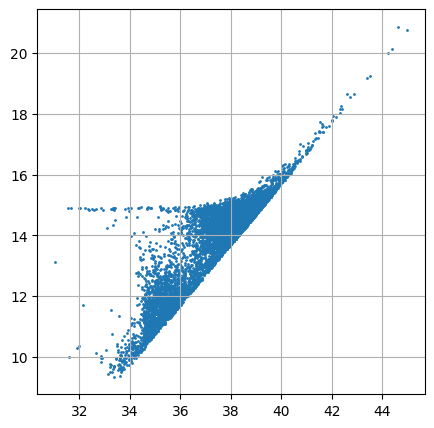

In [31]:
# Plot the finder_flux_abmag against catalog['ABmag'] to see if thats actually doing appropriate calibration
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(catalog['aperture_sum_abmag'], catalog['aperture_sum_abmag'] - catalog['ABmag'], s=1)
# ax.set_xlabel('aperture_sum_abmag')
# ax.set_ylabel('ABmag (calibrated from pjpipe cats) minus aperture_sum_abmag')
ax.grid()
plt.show()

---

---

### Testing and making QA plots (in progress!)

Everything below this cell can be ignored for now. The final step for making zero point corrected catalogs is the cell above. 

Number of sources in catalog: 10000
Calibrated magnitude range: 16.645858462577014 to 24.30050837878367


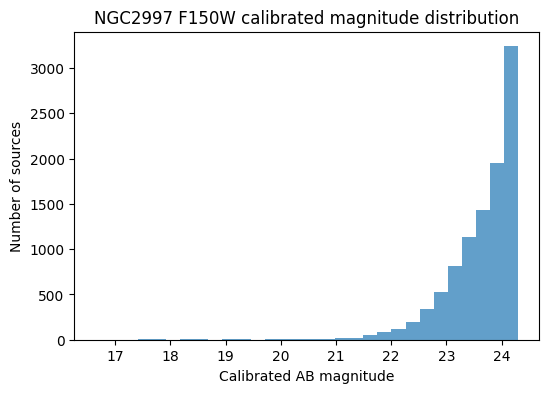

In [26]:
# Histogram of the calibrated magnitudes
plt.figure(figsize=(6, 4))
print(f"Number of sources in catalog: {len(catalog)}")
print(f"Calibrated magnitude range: {catalog['ABmag'].min()} to {catalog['ABmag'].max()}")
plt.hist(catalog['ABmag'], bins=30, alpha=0.7)
plt.xlabel('Calibrated AB magnitude')
plt.ylabel('Number of sources')
plt.title(f"{gal.upper()} {band.upper()} calibrated magnitude distribution")
plt.show()

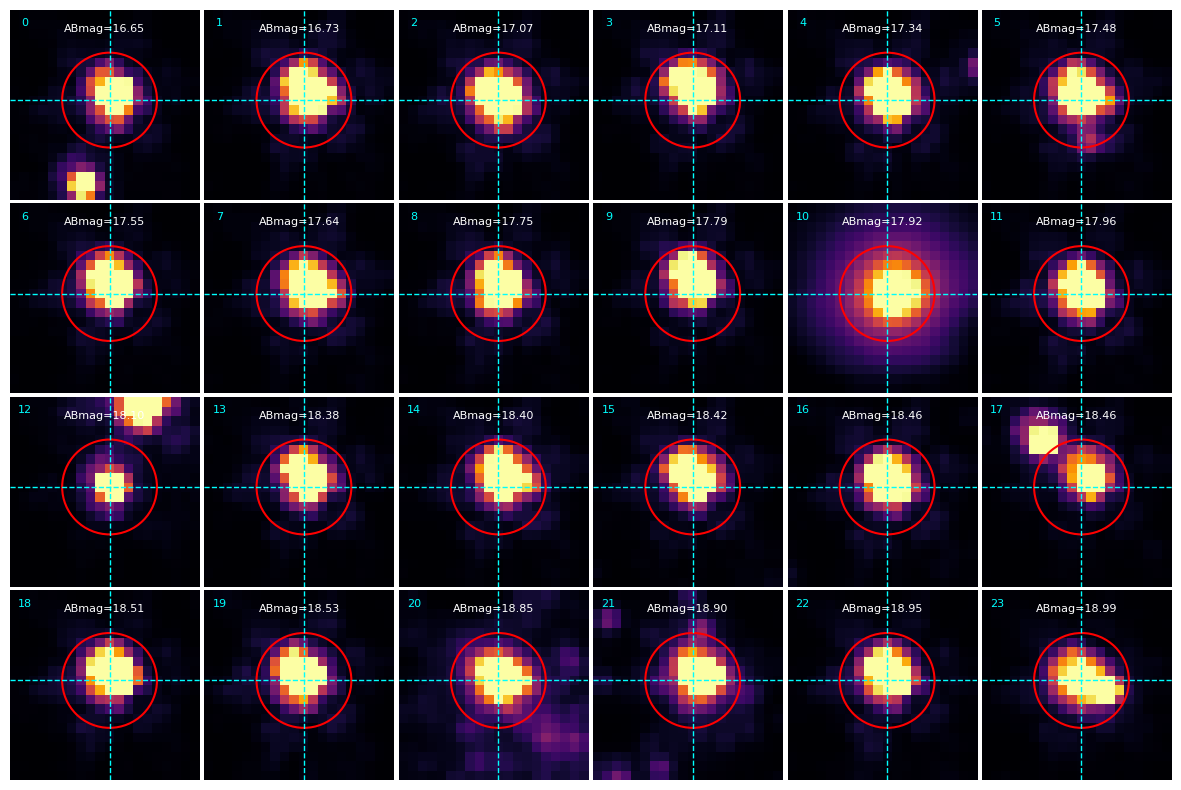

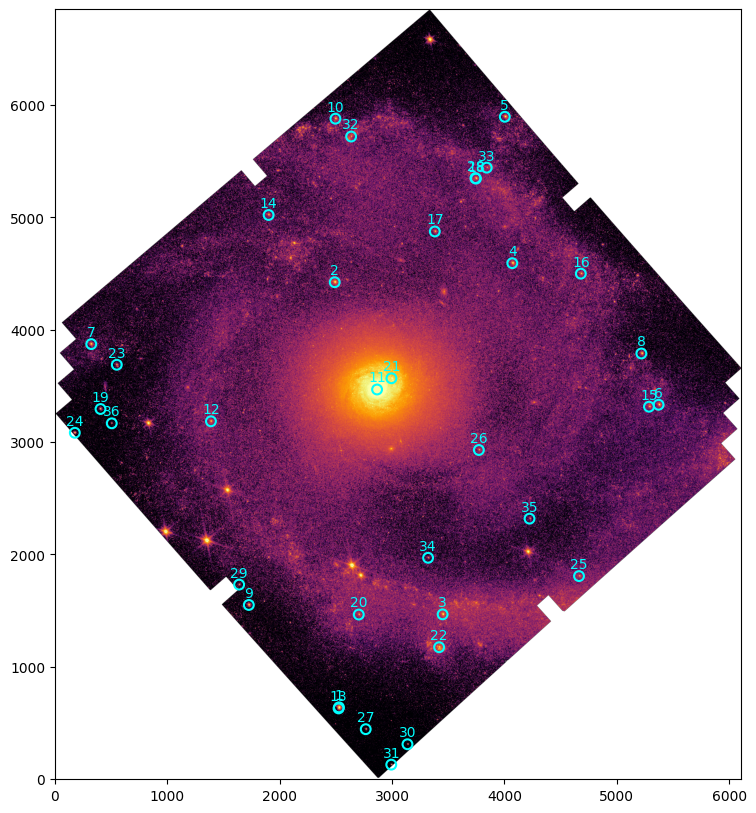

In [27]:
# Cutouts of the brightest sources
brightest_sources = cat70[np.argsort(cat70['ABmag'])[:36]]

fig, axes = plt.subplots(4, 6, figsize=(15, 10), gridspec_kw={'wspace': 0.02, 'hspace': 0.02})
for i, (ax, row) in enumerate(zip(axes.flatten(), brightest_sources)):
    x, y = row['xcenter'], row['ycenter']
    cutout_size = r_opt*2
    x_min, x_max = int(x - cutout_size), int(x + cutout_size)
    y_min, y_max = int(y - cutout_size), int(y + cutout_size)
    cutout = img_sub[y_min:y_max, x_min:x_max]
    norm_cutout = ImageNormalize(vmin=np.nanpercentile(cutout, 2), 
                                vmax=np.nanpercentile(cutout, 96))
    ax.imshow(cutout, origin='lower', cmap='inferno', norm=norm_cutout)
    # Plot horizontal and vertical lines through the center of the cutout
    ax.axhline(cutout_size, color='cyan', ls='--', lw=1.0)
    ax.axvline(cutout_size, color='cyan', ls='--', lw=1.0)
    # Draw a circle with radius equal to the optimal aperture radius
    circle = plt.Circle((cutout_size, cutout_size), r_opt, edgecolor='red', facecolor='none', lw=1.5, alpha=1.0)
    ax.add_patch(circle)
    ax.text(0.5, 0.9, f"ABmag={row['ABmag']:.2f}", color='white', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.08, 0.93, f"{i}", color='cyan', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

# Mosaic with all of these points highlighted
fig, ax = plt.subplots(figsize=(10, 10))
norm_mosaic = ImageNormalize(vmin=np.nanpercentile(img_sub, 25.00), 
                            vmax=np.nanpercentile(img_sub, 99.9),
                            stretch=LogStretch())
ax.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_mosaic)
ax.scatter(brightest_sources['xcenter'], brightest_sources['ycenter'], s=50, edgecolor='cyan', facecolor='none', lw=1.5, label='Brightest sources')
for i in range(len(brightest_sources)):
    # if brightest_sources['xcenter'][i] < 2400 or brightest_sources['xcenter'][i] > 2700 or brightest_sources['ycenter'][i] < 500 or brightest_sources['ycenter'][i] > 800:
        # continue
    # else:
    ax.text(brightest_sources['xcenter'][i], brightest_sources['ycenter'][i]+105, f"{i+1}", color='cyan', fontsize=10, ha='center', va='center')
# ax.set_xlim(2400, 2700)
# ax.set_ylim(500, 800)
plt.show()


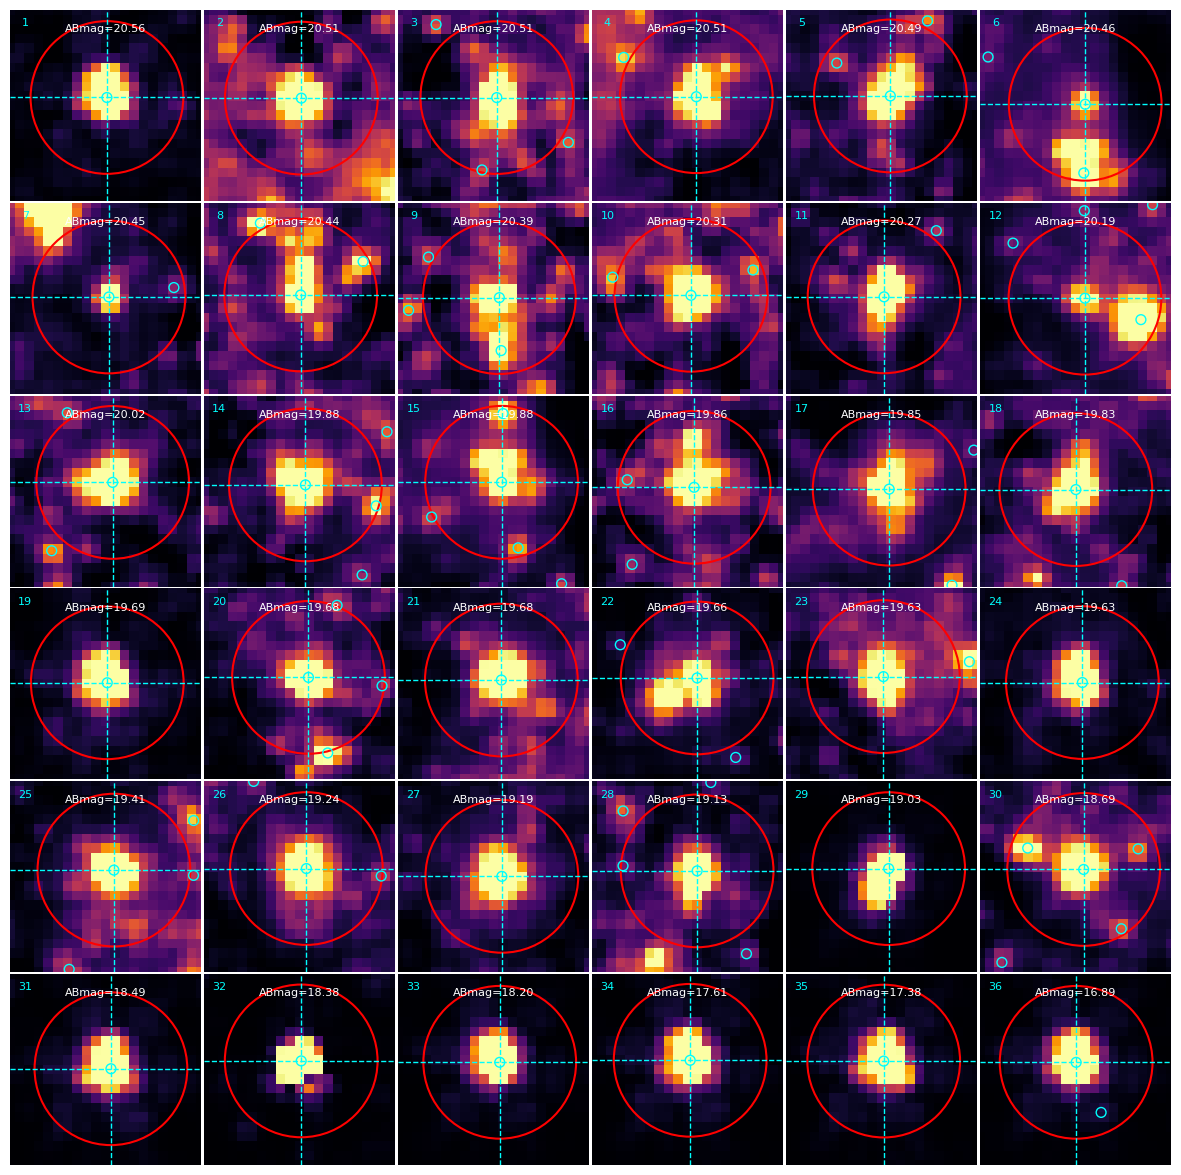

In [100]:
fig, axes = plt.subplots(6, 6, figsize=(15, 15), gridspec_kw={'wspace': 0.01, 'hspace': 0.01})
for i, (ax, row) in enumerate(zip(axes.flatten(), brightest_sources)):
    x, y = row['xcenter'], row['ycenter']
    cutout_size = r_opt*2
    x_min, x_max = int(x - cutout_size), int(x + cutout_size)
    y_min, y_max = int(y - cutout_size), int(y + cutout_size)
    cutout = img_sub[y_min:y_max, x_min:x_max]
    norm_cutout = ImageNormalize(vmin=np.nanpercentile(cutout, 2), 
                                vmax=np.nanpercentile(cutout, 96))
    ax.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_cutout)
    # Plot horizontal and vertical lines through the center of the cutout
    ax.axhline(y, color='cyan', ls='--', lw=1.0)
    ax.axvline(x, color='cyan', ls='--', lw=1.0)
    # Draw a circle with radius equal to the optimal aperture radius
    circle = plt.Circle((x, y), r_opt70, edgecolor='red', facecolor='none', lw=1.5, alpha=1.0)
    sky_in_circle = plt.Circle((x, y), max_r+2, edgecolor='magenta', facecolor='none', lw=1.5, alpha=0.5)
    sky_out_circle = plt.Circle((x, y), max_r+8, edgecolor='orange', facecolor='none', lw=1.5, alpha=0.5)  
    ax.add_patch(circle)
    ax.add_patch(sky_in_circle)
    ax.add_patch(sky_out_circle)
    ax.axis('off')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.text(0.5, 0.9, f"ABmag={row['ABmag']:.2f}", color='white', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.08, 0.93, f"{i+1}", color='cyan', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    # Select all sources in the catalog that are within the cutout region
    sources_in_cutout = cat70[(cat70['xcenter'] > x_min) & (cat70['xcenter'] < x_max) & (cat70['ycenter'] > y_min) & (cat70['ycenter'] < y_max)]
    ax.scatter(sources_in_cutout['xcenter'], sources_in_cutout['ycenter'], s=50, edgecolor='cyan', facecolor='none', lw=1.0)
plt.show()

Cutout limits: x=2608 to 2808, y=2958 to 3158
3095


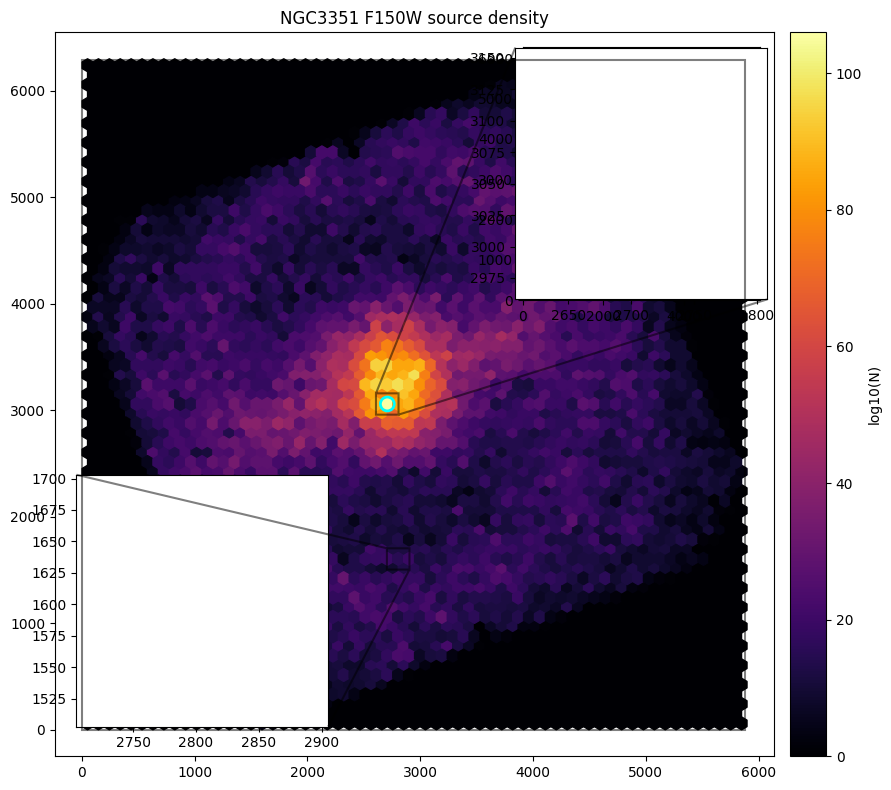

In [109]:
# Make a 2d histogram of the number density of sources in the catalog across the image
from matplotlib.patches import PathPatch
from matplotlib.path import Path

fig, ax = plt.subplots(figsize=(9, 8))
hb = ax.hexbin(catalog['xcenter'], catalog['ycenter'], gridsize=60, cmap='inferno', zorder=-1)
ax.set_title(f"{gal.upper()} {band.upper()} source density")
plt.colorbar(hb, ax=ax, label='log10(N)', pad=0.02, fraction=0.05)
# Extract info about the hexbins to get the location of the bin with the maximum value and plot a cutout of the image around that location
x_bin_edges = hb.get_offsets()[:, 0]
y_bin_edges = hb.get_offsets()[:, 1]
counts = hb.get_array()
max_bin_index = np.argmax(counts)
x_max_bin = x_bin_edges[max_bin_index]
y_max_bin = y_bin_edges[max_bin_index]

# Plot a cutout of the image around this location
cutout_size = 100
x_min, x_max = int(x_max_bin - cutout_size), int(x_max_bin + cutout_size)
y_min, y_max = int(y_max_bin - cutout_size), int(y_max_bin + cutout_size)
print(f"Cutout limits: x={x_min} to {x_max}, y={y_min} to {y_max}")
cutout = img_sub[y_min:y_max, x_min:x_max]
norm_cutout = ImageNormalize(vmin=np.nanpercentile(cutout, 2), 
                            vmax=np.nanpercentile(cutout, 96),
                            stretch=LogStretch(0.2))
# Add the cutout in a new plot, but mark the bin on the hexbin map
ax.scatter(x_max_bin, y_max_bin, s=100, edgecolor='cyan', facecolor='none', lw=2, label='Bin with max source density', zorder=500)

# Get the data for the hexagon corresponding to the bin with the maximum value
hexagon_center = hb.get_offsets()[max_bin_index]
verts = hb.get_paths()[0].vertices + hexagon_center
# Create inset axis
axins = ax.inset_axes([0.64, 0.63, 0.35, 0.35])
axins.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_cutout)
ax.indicate_inset_zoom(axins, edgecolor="black", zorder=10, lw=1.5)

# Plot the specific hexagon shape
# path = Path(verts, hb.get_paths()[0].codes)
# patch = PathPatch(path, facecolor='none', edgecolor='cyan', lw=2)
# axins.add_patch(patch)

# Now in the bottom left, add inset for ind len(hb)/2
mid_bin_index = 3095
print(mid_bin_index)
x_mid_bin = x_bin_edges[mid_bin_index]
y_mid_bin = y_bin_edges[mid_bin_index]

# Plot a cutout of the image around this location
cutout_size = 100
x_min_mid, x_max_mid = int(x_mid_bin - cutout_size), int(x_mid_bin + cutout_size)
y_min_mid, y_max_mid = int(y_mid_bin - cutout_size), int(y_mid_bin + cutout_size)
# cutout_mid = img_sub[y_min_mid:y_max_mid, x_min_mid:x_max_mid]
# norm_cutout_mid = ImageNormalize(vmin=np.nanpercentile(cutout_mid, 2), 
#                             vmax=np.nanpercentile(cutout_mid, 99))
# axins2 = ax.inset_axes([0.03, 0.04, 0.35, 0.35])
# axins2.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_cutout_mid)
# ax.indicate_inset_zoom(axins2, edgecolor="black", zorder=10, lw=1.5)
# axins2.set_xlim(x_min_mid, x_max_mid)
# axins2.set_ylim(y_min_mid, y_max_mid)
# axins2.set_xticks([])
# axins2.set_yticks([])
# axins2.text(0.5, 0.9, f"Bin with {counts[mid_bin_index]:.0f} sources", color='white', fontsize=10, ha='center', va='center', transform=axins2.transAxes)
# Add colourbar to axins2
# cbar = plt.colorbar(axins2.images[0], ax=axins2, pad=0.01, fraction=0.05)
# set cbar ticks white
# cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
# cbar = plt.colorbar(axins.images[0], ax=axins, pad=0.01, fraction=0.05)
# cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
# Show apertures in the inset
# apertures.plot(color='cyan', lw=1.5, alpha=0.5, ax=axins)

# Set up function for adding and plotting on the inset axes
coords1 = [0.64, 0.63, 0.35, 0.35]
coords2 = [0.03, 0.04, 0.35, 0.35]
def add_inset_with_cutout(ax, img, center_x, center_y, cutout_size, title, norm, coords):
    x_min, x_max = int(center_x - cutout_size), int(center_x + cutout_size)
    y_min, y_max = int(center_y - cutout_size), int(center_y + cutout_size)
    cutout = img[y_min:y_max, x_min:x_max]
    axins = ax.inset_axes(coords)
    norm_cutout = ImageNormalize(vmin=np.nanpercentile(cutout, 2), 
                                vmax=np.nanpercentile(cutout, 96),
                                stretch=LogStretch(0.2))
    axins.imshow(cutout, origin='lower', cmap='inferno', norm=norm_cutout)
    ax.indicate_inset_zoom(axins, edgecolor="black", zorder=10, lw=1.5)
    axins.set_xlim(x_min, x_max)
    axins.set_ylim(y_min, y_max)
    axins.text(0.5, 0.9, title, color='white', fontsize=10, ha='center', va='center', transform=axins.transAxes)
    # return axins

# Plot axins1 using the function
add_inset_with_cutout(ax, img_sub, x_max_bin, y_max_bin, cutout_size, f"Bin with {counts[max_bin_index]:.0f} sources", norm, coords1)
add_inset_with_cutout(ax, img_sub, x_mid_bin, y_mid_bin, cutout_size, f"Bin with {counts[mid_bin_index]:.0f} sources", norm, coords2)
# for axins in [axins1, axins2]:
#     axins.set_xticks([])
#     axins.set_yticks([])
#     cbar = plt.colorbar(axins.images[0], ax=axins, pad=0.01, fraction=0.05)
#     cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

# zoom_margin = cutout_size/1.2  # Adjust this value to control how much of the area around the hexagon is shown
# axins.set_xlim(hexagon_center[0] - zoom_margin/1.1, hexagon_center[0] + zoom_margin/1.1)
# axins.set_ylim(hexagon_center[1] - zoom_margin, hexagon_center[1] + zoom_margin)
# axins.set_xticks([])
# axins.set_yticks([])
# axins.text(0.5, 0.9, f"Bin with {counts[max_bin_index]:.0f} sources", color='white', fontsize=10, ha='center', va='center', transform=axins.transAxes)
plt.tight_layout()
plt.show()





### Aperture correction

For point sources, we can apply the aperture correction based on the CRDS reference file. This won't be accurate for extended/resolved sources such as clusters, as the PSF is more extended than APCORR accounts for, but it will do as a first approximation and for our point sources. TODO: end up filtering point sources using PSF photometry to get an 'extnded only' catalog. Might also be able to capture this with kron apertures. 

In [40]:
# path_to_crds = "/nexus/posix0/MIA-astro-env/eschinner/reho/jwst_pipeline/crds_cache/references/jwst/" + 'miri' + "/"
path_to_crds_nircam = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/" + 'nircam' + "/"
path_to_crds_miri = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/" + 'miri' + "/"
# Get the apcorr file using glob
apcorr_files_miri = glob.glob(path_to_crds_miri + f"*apcorr*")
# Load the file
apcorr_data = fits.getdata(apcorr_files_miri[1], ext=1)
# Print the column names of the apcorr data
print(f"Columns in the apcorr data: {apcorr_data.columns.names}")
# Print the data where filter='F1000W' and eefraction=50%
print(apcorr_data[(apcorr_data['filter'] == 'F1000W') & (apcorr_data['eefraction'] == 0.5)])
# Convert the radius at 50% encircled energy from arcseconds to pixels using the pixel scale for MIRI
pixel_scale_miri = 0.11 # arcsec/pixel
radius_50_eef_pixels = apcorr_data[(apcorr_data['filter'] == 'F1000W') & (apcorr_data['eefraction'] == 0.5) & (apcorr_data['subarray'] == 'FULL')]
print(radius_50_eef_pixels['radius'][0] * pixel_scale_miri)
# print(f"Radius at 50% encircled energy for F1000W in pixels: {radius_50_eef_pixels:.2f} pixels")


Columns in the apcorr data: ['filter', 'subarray', 'eefraction', 'radius', 'apcorr', 'skyin', 'skyout']
[('F1000W', 'FULL', 0.5, 2.2719126, 2.0131207, 6.486814, 11.022751)
 ('F1000W', 'BRIGHTSKY', 0.5, 2.2719126, 2.0131207, 6.486814, 11.022751)
 ('F1000W', 'SUB256', 0.5, 2.2719126, 2.0131207, 6.486814, 11.022751)
 ('F1000W', 'SUB128', 0.5, 2.2719126, 2.0131207, 6.486814, 11.022751)
 ('F1000W', 'SUB64', 0.5, 2.2719126, 2.0131207, 6.486814, 11.022751)]
0.24991038


In [102]:
# path_to_crds = "/nexus/posix0/MIA-astro-env/eschinner/reho/jwst_pipeline/crds_cache/references/jwst/" + 'miri' + "/"
path_to_crds = "/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/" + 'nircam' + "/"

# Get the apcorr file using glob
apcorr_files = glob.glob(path_to_crds + f"*apcorr*")
if len(apcorr_files) == 0:
    raise FileNotFoundError(f"No apcorr files found for {band} in {inst} at {path_to_crds}")
else:
    print(f"Found apcorr files: {apcorr_files}")

# Load the file
apcorr_data = fits.getdata(apcorr_files[0], ext=1)
print(f"APCORR data columns: {apcorr_data.columns.names}")

# Print all the unique filters in the apcorr file
print("Unique eefraction values:", np.unique(apcorr_data['eefraction']))

# Get data for a specific eefraction
eefraction_value = 0.70
row = apcorr_data[apcorr_data['eefraction'] == eefraction_value]

# Limit to a specific filter 
row = row[(row['filter'] == band.upper())]

# Extract values
# This doesn't work at the moment because I only have the apcorr file for MIRI.
# Need to get the apcorr file for NIRCam, borrowing Jay's for now.
radius = row['radius'][0]  # in pixels
sky_in = row['skyin'][0]  # in pixels
sky_out = row['skyout'][0]  # in pixels
apcorr = row['apcorr'][0]  # aperture correction factor
print(f"Using aperture correction factor of {apcorr} for radius {radius} pixels and eefraction {eefraction_value}")

# Create apertures for aperture correction, not using the curve of growth
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
# Redo the aperture photometry using the radius, sky_in, and sky_out from the apcorr file
aperture = CircularAperture(positions, r=radius)
sky_annulus = CircularAnnulus(positions, r_in=sky_in, r_out=sky_out)

# Perform the photometry for the aperture and the sky annulus
wcs_apcorr = WCS(header)
phot_table_apcorr = aperture_photometry(img_sub, aperture, wcs=wcs_apcorr, method='subpixel', subpixels=5)
sky_table_apcorr = aperture_photometry(img_sub, sky_annulus, wcs=wcs_apcorr, method='subpixel', subpixels=5)

# Extract flux and sky
fluxes = phot_table_apcorr['aperture_sum'].value  # MJy/sr
sky_mean = sky_table_apcorr['aperture_sum'].value / sky_annulus.area  # MJy/sr
sky_total = sky_mean * aperture.area  # Total sky in aperture

# Correct for sky
net_fluxes = fluxes - sky_total  # Net flux in MJy/sr

# Apply aperture correction (multiplicative)
total_fluxes = net_fluxes * apcorr  # Now in MJy/sr

# Get pixel area in steradians (from header)
pixarea_sr = header['PIXAR_SR']  # in steradians

# Total flux in MJy/sr → total flux in Jy
total_flux_jy = total_fluxes * 1e6  # MJy → Jy

# Convert to AB magnitude
# abmag = -2.5 * np.log10(total_flux_jy * pixarea_sr) + 21.10
abmag_apcorr = -2.5 * np.log10(total_flux_jy * pixarea_sr) + 8.90  

# Add column to the phot_table_apcorr with the aperture-corrected AB magnitudes
phot_table_apcorr['ABmag_apcorr'] = abmag_apcorr

from astropy.table import join
merged_table = join(phot_table_apcorr, catalog, keys=['xcenter', 'ycenter'])
print(merged_table.colnames)

# Add the aperture-corrected AB magnitudes to the catalog
# catalog['ABmag_apcorr'] = phot_table_apcorr['ABmag_apcorr'][idx_apcorr]

Found apcorr files: ['/nexus/posix0/MIA-astro-env/eschinner/jgonzalez/jwst_pipeline/crds_cache/jwst_ops/references/jwst/nircam/jwst_nircam_apcorr_0004.fits']
APCORR data columns: ['filter', 'pupil', 'eefraction', 'radius', 'apcorr', 'skyin', 'skyout']
Unique eefraction values: [0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.85 0.9 ]
Using aperture correction factor of 1.4485000371932983 for radius 3.1989998817443848 pixels and eefraction 0.7


Set OBSGEO-B to    11.190755 from OBSGEO-[XYZ].
Set OBSGEO-H to 1691818680.709 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


['id_1', 'xcenter', 'ycenter', 'sky_center', 'aperture_sum_1', 'ABmag_apcorr', 'id_2', 'aperture_sum_2', 'flux', 'sharpness', 'roundness', 'finder_mag', 'peak', 'ra', 'dec', 'finder_flux_abmag', 'aperture_sum_abmag', 'ABmag']


/tmp/ipykernel_2810769/3429304789.py:64: RuntimeWarning: invalid value encountered in log10
  abmag_apcorr = -2.5 * np.log10(total_flux_jy * pixarea_sr) + 8.90


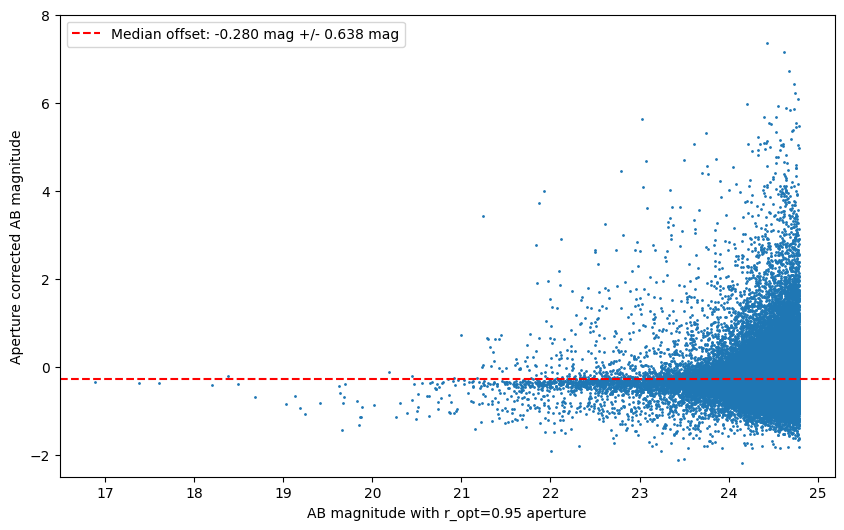

In [103]:
# Plot the photometry results with r_opt against the aperture corrected photometry
fig, ax = plt.subplots(figsize=(10, 6))
# If either ABmag or ABmag_apcorr is NaN, remove those points from the plot
mask = np.isfinite(merged_table['ABmag']) & np.isfinite(merged_table['ABmag_apcorr'])
merged_table_plot = merged_table[mask]

mag_diff = merged_table_plot['ABmag_apcorr'] - merged_table_plot['ABmag']
ax.scatter(merged_table_plot['ABmag'], mag_diff, s=1)
# ax.hist2d(merged_table_plot['ABmag'], mag_diff, bins=250, cmap='inferno')
# Plot a 1:1 line for reference
min_mag = min(np.nanmin(merged_table_plot['ABmag']), np.nanmin(merged_table_plot['ABmag_apcorr']))
max_mag = max(np.nanmax(merged_table_plot['ABmag']), np.nanmax(merged_table_plot['ABmag_apcorr']))
ax.axhline(np.nanmedian(mag_diff), color='red', linestyle='--', label=f'Median offset: {np.nanmedian(mag_diff):.3f} mag +/- {np.nanstd(mag_diff):.3f} mag')
# ax.plot([min_mag, max_mag], [min_mag, max_mag], color='red', linestyle='--')
# ax.set_xlim(22, 25)
ax.set_ylim(-2.5, 8)
ax.set_xlabel('AB magnitude with r_opt=0.95 aperture')
ax.set_ylabel('Aperture corrected AB magnitude')
ax.legend()
plt.show()

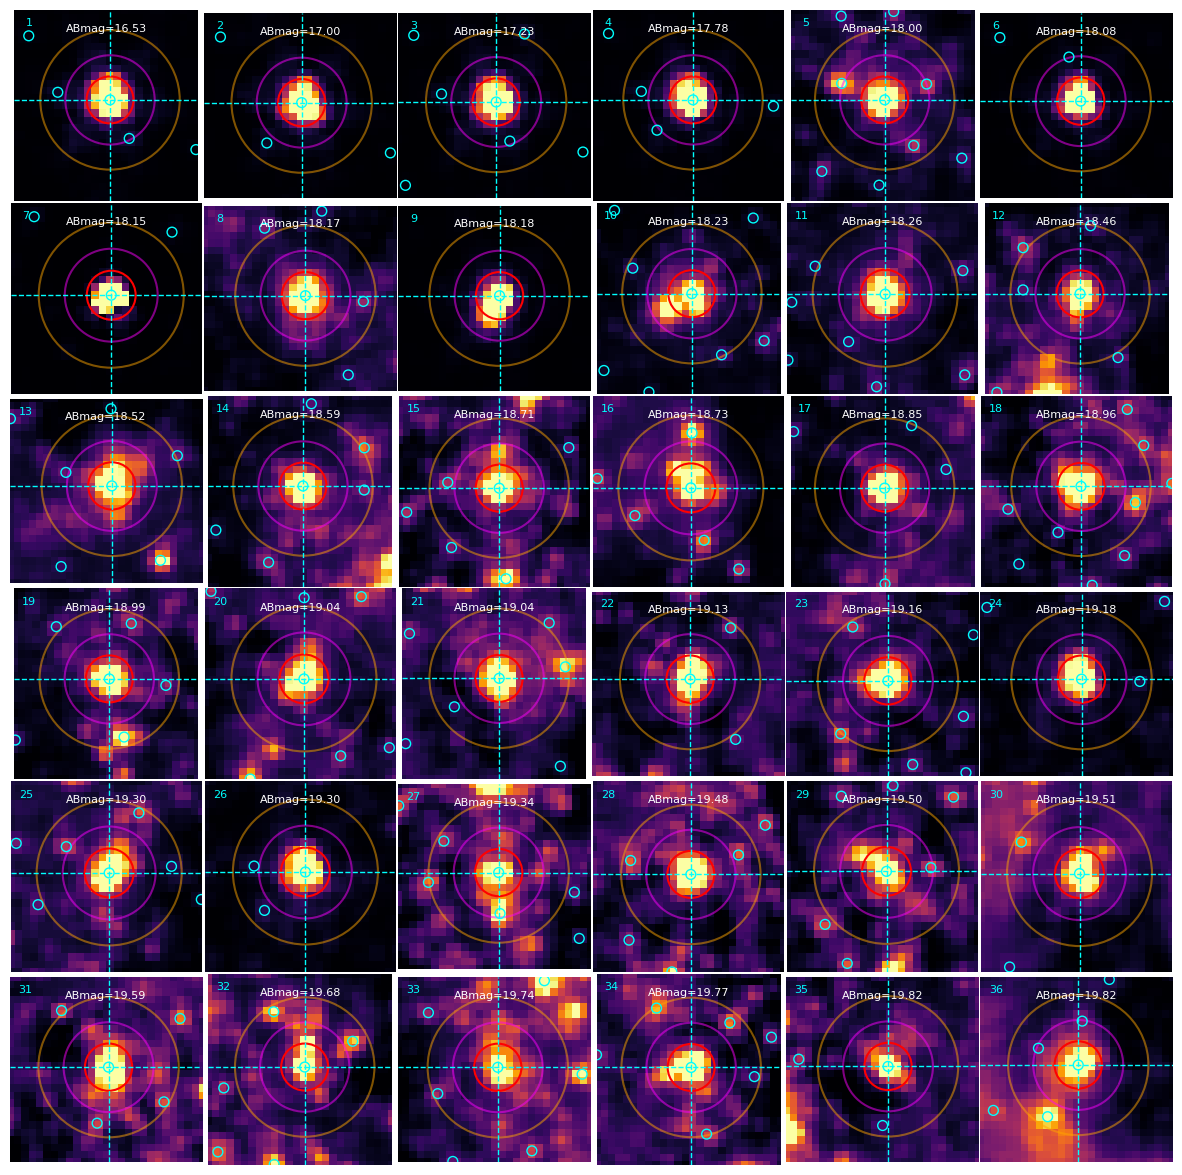

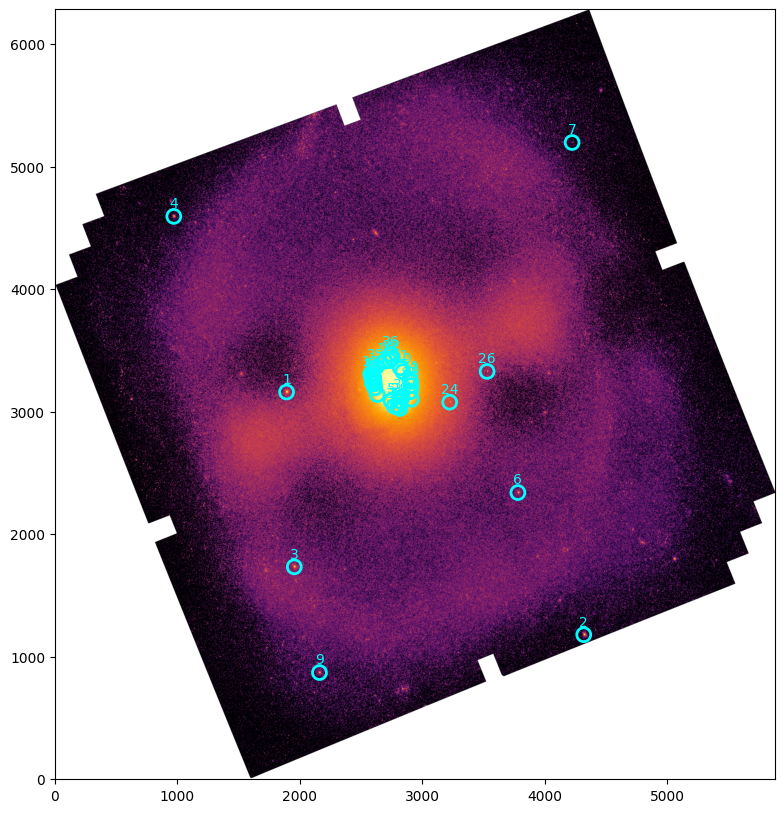

In [105]:
# Make the 6x6 plot of source cutouts using sources from the aperture corrected catalog
brightest_sources_apcorr = merged_table[np.argsort(merged_table['ABmag_apcorr'])][:36]
fig, axes = plt.subplots(6, 6, figsize=(15, 15), gridspec_kw={'wspace': 0.01, 'hspace': 0.01})
for i, (ax, row) in enumerate(zip(axes.flatten(), brightest_sources_apcorr)):
    x, y = row['xcenter'], row['ycenter']
    cutout_size = radius*4
    x_min, x_max = int(x - cutout_size), int(x + cutout_size)
    y_min, y_max = int(y - cutout_size), int(y + cutout_size)
    cutout = img_sub[y_min:y_max, x_min:x_max]
    norm_cutout = ImageNormalize(vmin=np.nanpercentile(cutout, 2), 
                                vmax=np.nanpercentile(cutout, 98))
    ax.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_cutout)
    # Plot horizontal and vertical lines through the center of the cutout
    ax.axhline(y, color='cyan', ls='--', lw=1.0)
    ax.axvline(x, color='cyan', ls='--', lw=1.0)
    # Draw a circle with radius equal to the optimal aperture radius
    circle = plt.Circle((x, y), radius, edgecolor='red', facecolor='none', lw=1.5, alpha=1.0)
    sky_in_circle = plt.Circle((x, y), sky_in, edgecolor='magenta', facecolor='none', lw=1.5, alpha=0.5)
    sky_out_circle = plt.Circle((x, y), sky_out, edgecolor='orange', facecolor='none', lw=1.5, alpha=0.5)  
    ax.add_patch(circle)
    ax.add_patch(sky_in_circle)
    ax.add_patch(sky_out_circle)
    ax.axis('off')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.text(0.5, 0.9, f"ABmag={row['ABmag_apcorr']:.2f}", color='white', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.08, 0.93, f"{i+1}", color='cyan', fontsize=8, ha='center', va='center', transform=ax.transAxes)
    # Select all sources in the catalog that are within the cutout region
    sources_in_cutout = merged_table[(merged_table['xcenter'] > x_min) & (merged_table['xcenter'] < x_max) & (merged_table['ycenter'] > y_min) & (merged_table['ycenter'] < y_max)]
    ax.scatter(sources_in_cutout['xcenter'], sources_in_cutout['ycenter'], s=50, edgecolor='cyan', facecolor='none', lw=1.0)
plt.show()

# And the mosaic with these sources highlighted
fig, ax = plt.subplots(figsize=(10, 10))
norm_mosaic = ImageNormalize(vmin=np.nanpercentile(img_sub, 25.00), 
                            vmax=np.nanpercentile(img_sub, 99.9),
                            stretch=LogStretch())
ax.imshow(img_sub, origin='lower', cmap='inferno', norm=norm_mosaic)
# ax.scatter(merged_table['xcenter'], merged_table['ycenter'], s=20, edgecolor='cyan', facecolor='none', lw=1.5, label='Sources in aperture-corrected catalog')
for i in range(len(brightest_sources_apcorr)):
    ax.scatter(brightest_sources_apcorr['xcenter'][i], brightest_sources_apcorr['ycenter'][i], s=100, edgecolor='cyan', facecolor='none', lw=2, label='Brightest sources in aperture-corrected catalog' if i==0 else "")
    ax.text(brightest_sources_apcorr['xcenter'][i], brightest_sources_apcorr['ycenter'][i]+105, f"{i+1}", color='cyan', fontsize=10, ha='center', va='center')
plt.show()

## CMDs colour coded through sharpness and soundness